### Linear Regression (multiple features) from Scratch without any built-in Libraries (except Numpy and Matplotlib)


In [48]:
import numpy as np

In [49]:
def predict(x, w, b):
    prediction = np.dot(w, x) + b  # linear regression formula for single feature
    return prediction

In [50]:
def compute_cost(X, y, w, b):
    cost = 0
    m = len(X)

    for i in range(m):
        prediction = predict(X[i], w, b)
        error = prediction - y[i]   # predicted - actual
        cost += error ** 2
    
    cost = cost / (2 * m)   # here multiplying by 2 makes it easy to find the derivative for gradient descent

    return cost

In [51]:
def compute_gradient(X, y, w, b):
    dj_dw = np.zeros(X.shape[1])
    dj_db = 0
    m = len(X)

    for i in range(m):
        prediction = predict(X[i], w, b)
        
        error = prediction - y[i]
        dj_dw += error * X[i]   # derivative of cost function w.r.t "w"
        dj_db += error  # # derivative of cost function w.r.t "w"

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db 

In [52]:
def gradient_descent(X, y, w, b, alpha=0.0001, iterations=100000):

    cost_history = []

    for i in range(iterations):
        cost = compute_cost(X, y, w, b)
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw   # update weight
        b = b - alpha * dj_db   # update bias
        cost_history.append(cost)

    return w, b, cost_history


In [53]:
def train(X, y, alpha=0.0001, iterations=100000):
    w = np.zeros(X.shape[1])
    b = 0

    w, b, cost_history = gradient_descent(X, y, w, b)

    return w, b, cost_history

In [54]:
import pandas as pd

fish_data = pd.read_csv("Fish.csv")
fish_data.head()

fish_data = fish_data.drop(columns=['Species'])

In [55]:
fish_data.head()

,Weight,Length1,Length2,Length3,Height,Width
0,242.0,23.2,25.4,30.0,11.5200,4.0200
1,290.0,24.0,26.3,31.2,12.4800,4.3056
2,340.0,23.9,26.5,31.1,12.3778,4.6961
3,363.0,26.3,29.0,33.5,12.7300,4.4555
4,430.0,26.5,29.0,34.0,12.4440,5.1340


In [56]:
fish_data.info()
fish_data.shape
fish_data.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Weight   159 non-null    float64
 1   Length1  159 non-null    float64
 2   Length2  159 non-null    float64
 3   Length3  159 non-null    float64
 4   Height   159 non-null    float64
 5   Width    159 non-null    float64
dtypes: float64(6)
memory usage: 7.6 KB


Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [57]:
fish_data.agg(["max", "min", "mean"]).round()

,Weight,Length1,Length2,Length3,Height,Width
max,1650.0,59.0,63.0,68.0,19.0,8.0
min,0.0,8.0,8.0,9.0,2.0,1.0
mean,398.0,26.0,28.0,31.0,9.0,4.0


In [58]:
X = fish_data.drop(columns=['Weight'])
y = fish_data['Weight']

X = X.to_numpy()
y = y.to_numpy()

w, b, cost_history = train(X, y)
print(f"Optimal values for w and b:")
print(f"w = {w}")
print(f"b = {b:.2f}")

print(f"\nFormula (Hypothesis):")
print(f"f(x) = {w.round(2)}x + {b:.2f}")
print(cost_history)

Optimal values for w and b:
w = [ 66.40145769   8.87012348 -49.214599    36.21765438  -5.13993931]
b = -344.49

Formula (Hypothesis):
f(x) = [ 66.4    8.87 -49.21  36.22  -5.14]x + -344.49
[np.float64(143003.22141509436), np.float64(83337.03074364125), np.float64(53502.325909836145), np.float64(38583.94005706983), np.float64(31124.001992670484), np.float64(27393.432232004674), np.float64(25527.619085270097), np.float64(24594.22073187516), np.float64(24127.04827242646), np.float64(23892.998261774483), np.float64(23775.51447888869), np.float64(23716.316563384644), np.float64(23686.263209538833), np.float64(23670.783201150072), np.float64(23662.59064788641), np.float64(23658.042462911133), np.float64(23655.31703141948), np.float64(23653.503509767266), np.float64(23652.146457465027), np.float64(23651.018144389163), np.float64(23650.004699994894), np.float64(23649.04918572593), np.float64(23648.12313012108), np.float64(23647.212295818375), np.float64(23646.309562782462), np.float64(23645.41

In [59]:
prediction = predict(X[23], w, b)
print(f"Prediction for the weight based on these features:\n{fish_data.iloc[23, 1:]}")
print(f"Predicted Weight: {prediction:.2f}")
print(f"Actual Weight: {y[23]}")

Prediction for the weight based on these features:
Length1    31.8000
Length2    35.0000
Length3    40.6000
Height     15.4686
Width       6.1306
Name: 23, dtype: float64
Predicted Weight: 608.14
Actual Weight: 680.0


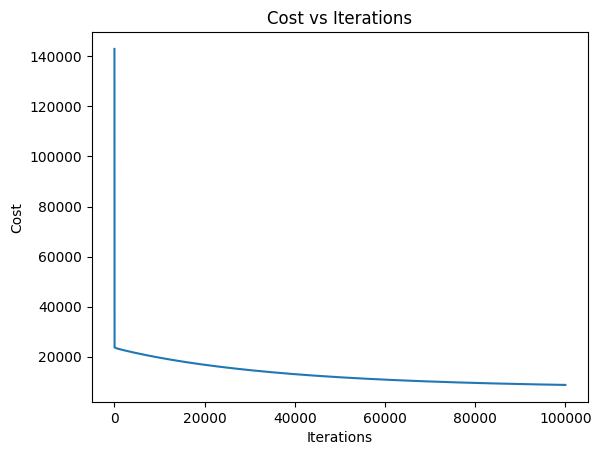

In [60]:
import matplotlib.pyplot as plt

# plot the cost 
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")
plt.show()